# Baie des Moutons syenite ca. 583 Ma paleomagnetic poles (ChRM A and ChRM B)

## Geologic context

The Baie des Moutons (Mutton Bay) syenite is a ~20 km diameter alkalic complex emplaced in Grenville gneiss along the Quebec north shore of the Gulf of St. Lawrence (McCausland et al., 2011). It is part of the latest-Neoproterozoic, rift-related alkalic to carbonatitic magmatism that heralded the development of Laurentia's early Paleozoic Iapetan passive margin. Detailed mapping (Davies, 1968) recognized 23 intrusive units ranging from syenitic to quartz-syenitic in composition, together with numerous syn-intrusive microsyenite and aplite dykes and late mafic to carbonatitic dykes. The ovoid plan, the distribution of radial and concentric dykes, and the general centreward dip of intrusive contacts has been interpretted to be consistent with rift-setting intrusions. The varied strikes and steep dips of its dykes are interpreted to indicate that the complex has not been significantly tilted since emplacement, so the paleomagnetic directions are interpreted in geographic (in-situ) coordinates with no tilt correction. 

## Paleomagnetic and rock magnetic data

Forty-four sites (530 specimens) were demagnetized by stepwise thermal and alternating-field methods, with principal-component (best-fit line) and great-circle (best-fit plane) analysis; low-temperature demagnetization (LTD) was used to strip a viscous remanence carried by multidomain (MD) magnetite. Two characteristic components were isolated. Importantly, there are not observed to coexist:

- **ChRM A** — eight 'steep' syenite sites, easterly and steep (D = 98.6°, I = 78.0°; α95 = 6.6°, k = 71.7), defined over unblocking temperatures >450 °C and coercivities >20 mT and retained by pseudo-single-domain (PSD) magnetite. Its paleopole at 42.6°N, 332.7°E places Laurentia at high paleolatitude.
- **ChRM B** — six 'shallow' sites from feldspar-porphyry, aplite and carbonatite dykes plus the late red-syenite site MB20, directed shallowly to the south-southeast or northwest (D = 163.1°, I = 6.0°; α95 = 21.7°, k = 10.5) and removed over a somewhat lower stability range than ChRM A. Site MB20 carries the reversed (northwesterly) direction and is inverted for inclusion, implying at least one reversal during acquisition of ChRM B. Its paleopole at −34.2°N, 321.5°E places Laurentia at low paleolatitude.

Paleomagnetic baked-contact tests sampled at six sites (MB13–14, MB15, MB16, MB22, MB26, MB36) were all inconclusive, owing to the lack of a stable, non-VRM remanence in the host syenite. The two poles are enigmatic — providing support for both high- (ChRM A) and low-latitude (ChRM B) interpretations of mid-Ediacaran Laurentia — and both have been given B grades.

## Age constraints

- ⁴⁰Ar–³⁹Ar geochronology are used to constrain the age with the weighted-mean of four hornblende plateau ages giving **583.4 ± 2.0 Ma** (McCausland et al., 2011), which dates the complex and is the current age constraint on the poles. (An older whole-rock K–Ar age of 575 Ma was reported by Doig & Barton, 1968.)

Previous Nordic compilation stated that: *583.4±2.0 weighted mean of four hornblende 40Ar–39Ar plateau ages from sites 20 and 44, McCausland et al 2011*

## References

- McCausland, P. J. A., Hankard, F., Van der Voo, R., & Hall, C. M. (2011). Ediacaran paleogeography of Laurentia: Paleomagnetism and ⁴⁰Ar–³⁹Ar geochronology of the 583 Ma Baie des Moutons syenite, Quebec. *Precambrian Research*, 187(1–2), 58–78. https://doi.org/10.1016/j.precamres.2011.02.004
- Davies, J. F. (1968). *Geology and mineral deposits of the Mutton Bay area, Saguenay County, Quebec.* (Geological mapping of the complex.)
- Lalonde, A. E., & Martin, R. F. (1983). The Baie-des-Moutons syenitic complex, La Tabatière, Québec. *Canadian Mineralogist*, 21, 65–79.

In [1]:
import pole_tools as pt
import pmagpy.ipmag as ipmag
import pmagpy.pmag as pmag
import matplotlib.pyplot as plt

%config InlineBackend.figure_format='retina'
%matplotlib inline

## Site-level data

The 14 ChRM-bearing site means are loaded from this pole's MagIC-format `sites.txt`, assembled from Table 1 of McCausland et al. (2011) by `contribution_build/BaieDesMoutons_build_contribution.py` (there is no measurement-level MagIC contribution for this study). Each site is tagged `dir_comp_name` `A` or `B`; all are in geographic coordinates (`dir_tilt_correction = 0`), and the VGP and its dp/dm are computed from each site mean direction. The build writes two MagIC locations — one per component/pole. How the contribution is assembled is documented in `contribution_build/`.

In [2]:
sites_geo, sites_tc = pt.load_magic_sites('../data/583_Baie_des_Moutons/sites.txt')
sites_A = sites_geo[sites_geo['dir_comp_name'] == 'A'].reset_index(drop=True)
sites_B = sites_geo[sites_geo['dir_comp_name'] == 'B'].reset_index(drop=True)
print(f'{len(sites_A)} ChRM A sites, {len(sites_B)} ChRM B sites')
sites_geo[['site', 'dir_comp_name', 'lat', 'lon', 'dir_dec', 'dir_inc',
           'dir_k', 'dir_alpha95', 'vgp_lat', 'vgp_lon', 'vgp_dp', 'vgp_dm',
           'dir_n_samples', 'lithologies']]

8 ChRM A sites, 6 ChRM B sites


,site,dir_comp_name,lat,lon,dir_dec,dir_inc,dir_k,dir_alpha95,vgp_lat,vgp_lon,vgp_dp,vgp_dm,dir_n_samples,lithologies
0,MB03,A,50.8073,301.0230,109.2,80.8,41.5,7.2,42.3,324.2,13.4,13.9,11,Syenite
1,MB04,A,50.8108,301.0232,82.9,79.4,54.7,7.1,48.9,333.0,12.9,13.5,9,Syenite
2,MB05,A,50.8113,301.0228,141.5,82.8,68.8,9.3,39.1,312.4,17.8,18.2,5,Syenite
3,MB15,A,50.7958,301.0063,94.5,64.4,10.8,19.1,31.7,355.2,24.4,30.5,5,Syenite
4,MB19,A,50.8607,301.0055,46.4,73.6,46.1,11.4,62.8,354.4,18.4,20.5,5,Aplite
5,MB25,A,50.9102,301.0412,78.7,79.7,62.9,9.7,50.5,332.8,17.7,18.5,5,Aplite
6,MB26,A,50.9102,301.0412,136.0,80.7,81.5,8.5,36.6,316.7,15.8,16.4,5,Mafic Dike
7,MB44,A,50.8282,301.0375,124.0,69.2,46.0,7.3,23.8,334.3,10.6,12.4,10,Syenite
8,MB06,B,50.8070,301.0085,183.8,-5.9,80.1,5.9,-42.0,295.9,3.0,5.9,9,Aplite
9,MB11,B,50.7972,301.0108,162.8,-3.7,325.0,4.4,-38.9,323.3,2.2,4.4,5,Syenite


## Site location map

ChRM A (steep) sites are in the main syenite units; ChRM B (shallow) sites are predominantly in the feldspar-porphyry, aplite, and carbonatite dykes plus the late red-syenite site MB20.

In [3]:
pt.plot_site_map(sites_geo, zoom_start=9)

## Study locality

The mean complex locality (50°50.4′N, 58°57.6′W ≈ 50.84°N, 301.04°E) is used for the secular-variation diagnostics and the Nordic summary locality coordinates.

In [4]:
study_lat = 50.84
study_lon = 301.04

# ChRM A direction pole

The ChRM A pole is the Fisher mean of the 8 site VGPs (A direction). ChRM A is steep and easterly, placing Laurentia at high paleolatitude (~67deg).

## Mean pole from VGPs (ChRM A)

Plon: 331.9  Plat: 42.9
Number of directions in mean (n): 8
Angular radius of 95% confidence (A_95): 11.5
Precision parameter (k) estimate: 24.0


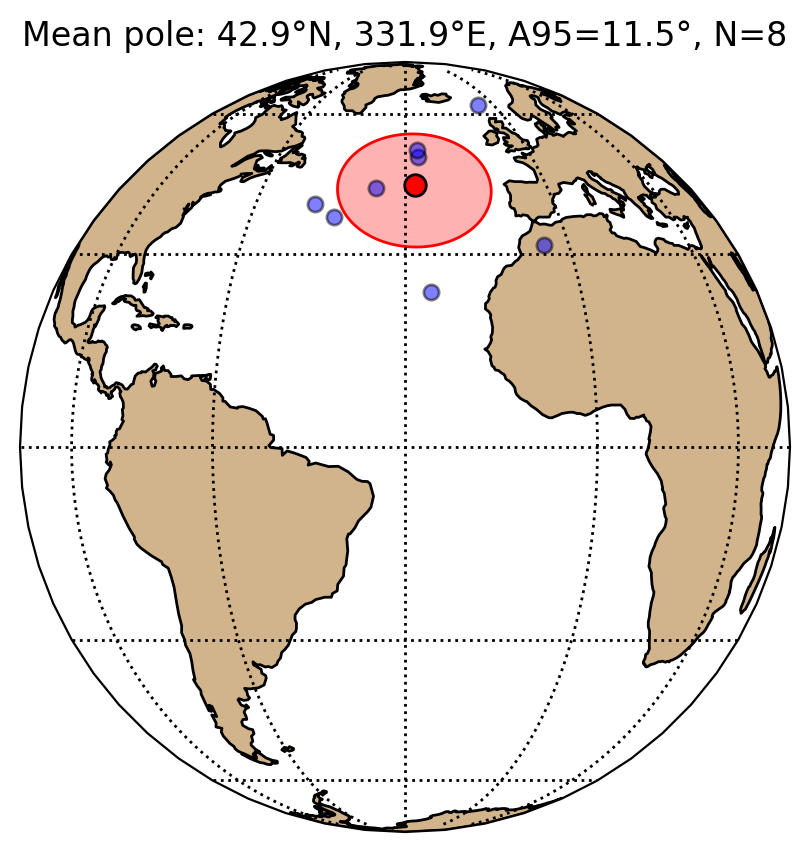

In [5]:
vgp_block_A, pole_mean_A = pt.compute_mean_pole(sites_A, unify_polarity=True)
ipmag.print_pole_mean(pole_mean_A)
pole_plot_A = pt.plot_vgps_and_pole(vgp_block_A, pole_mean_A, central_longitude=330, figsize=(5,5))

## Site directions (ChRM A, as measured)

Reproduces the published mean direction (D=98.6, I=78.0, a95=6.6, k=71.7).

Dec: 98.6  Inc: 78.0
Number of directions in mean (n): 8
Angular radius of 95% confidence (a_95): 6.6
Precision parameter (k) estimate: 71.8


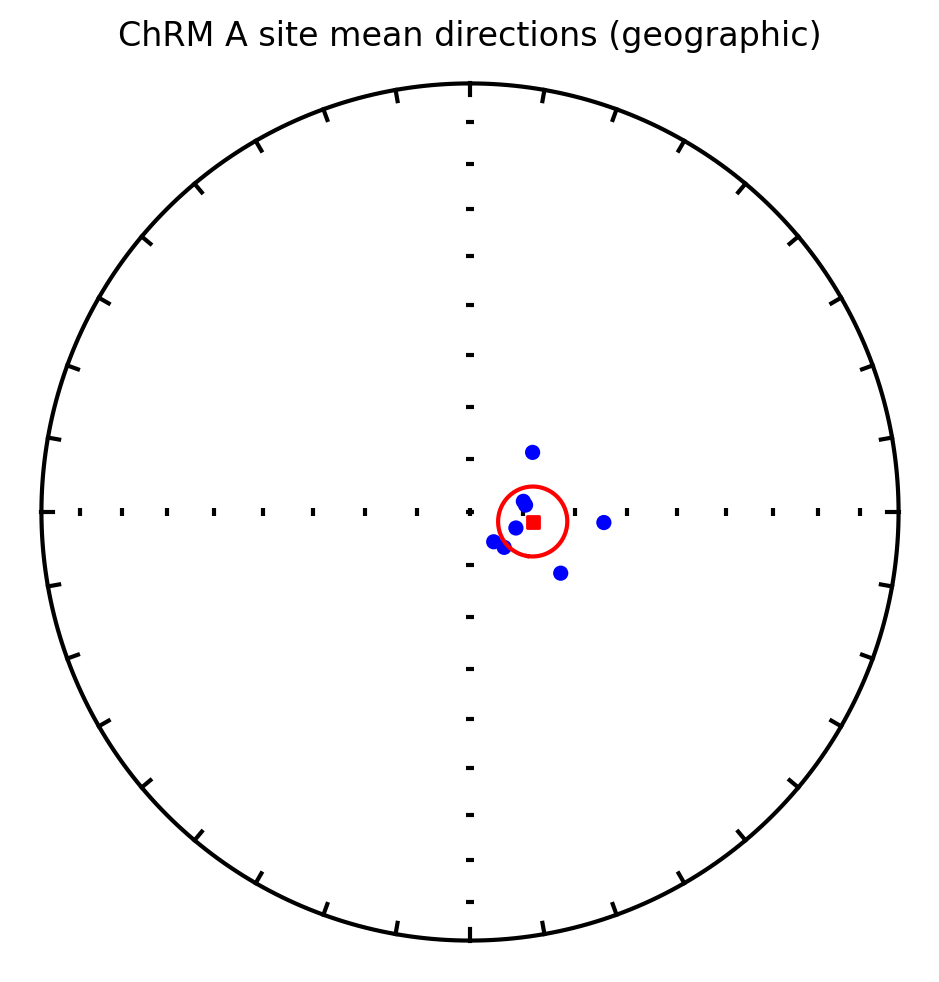

In [6]:
dir_block_A, dir_mean_A = pt.compute_mean_direction(sites_A, unify_polarity=True)
ipmag.print_direction_mean(dir_mean_A)

ipmag.plot_net()
ipmag.plot_di(di_block=dir_block_A, color='blue', marker='o')
ipmag.plot_di_mean(dir_mean_A['dec'], dir_mean_A['inc'], dir_mean_A['alpha95'],
                   color='red', marker='s')
ipmag.plt.title('ChRM A site mean directions (geographic)')
ipmag.plt.show()

## Pole in the context of the Laurentia APWP (ChRM A)

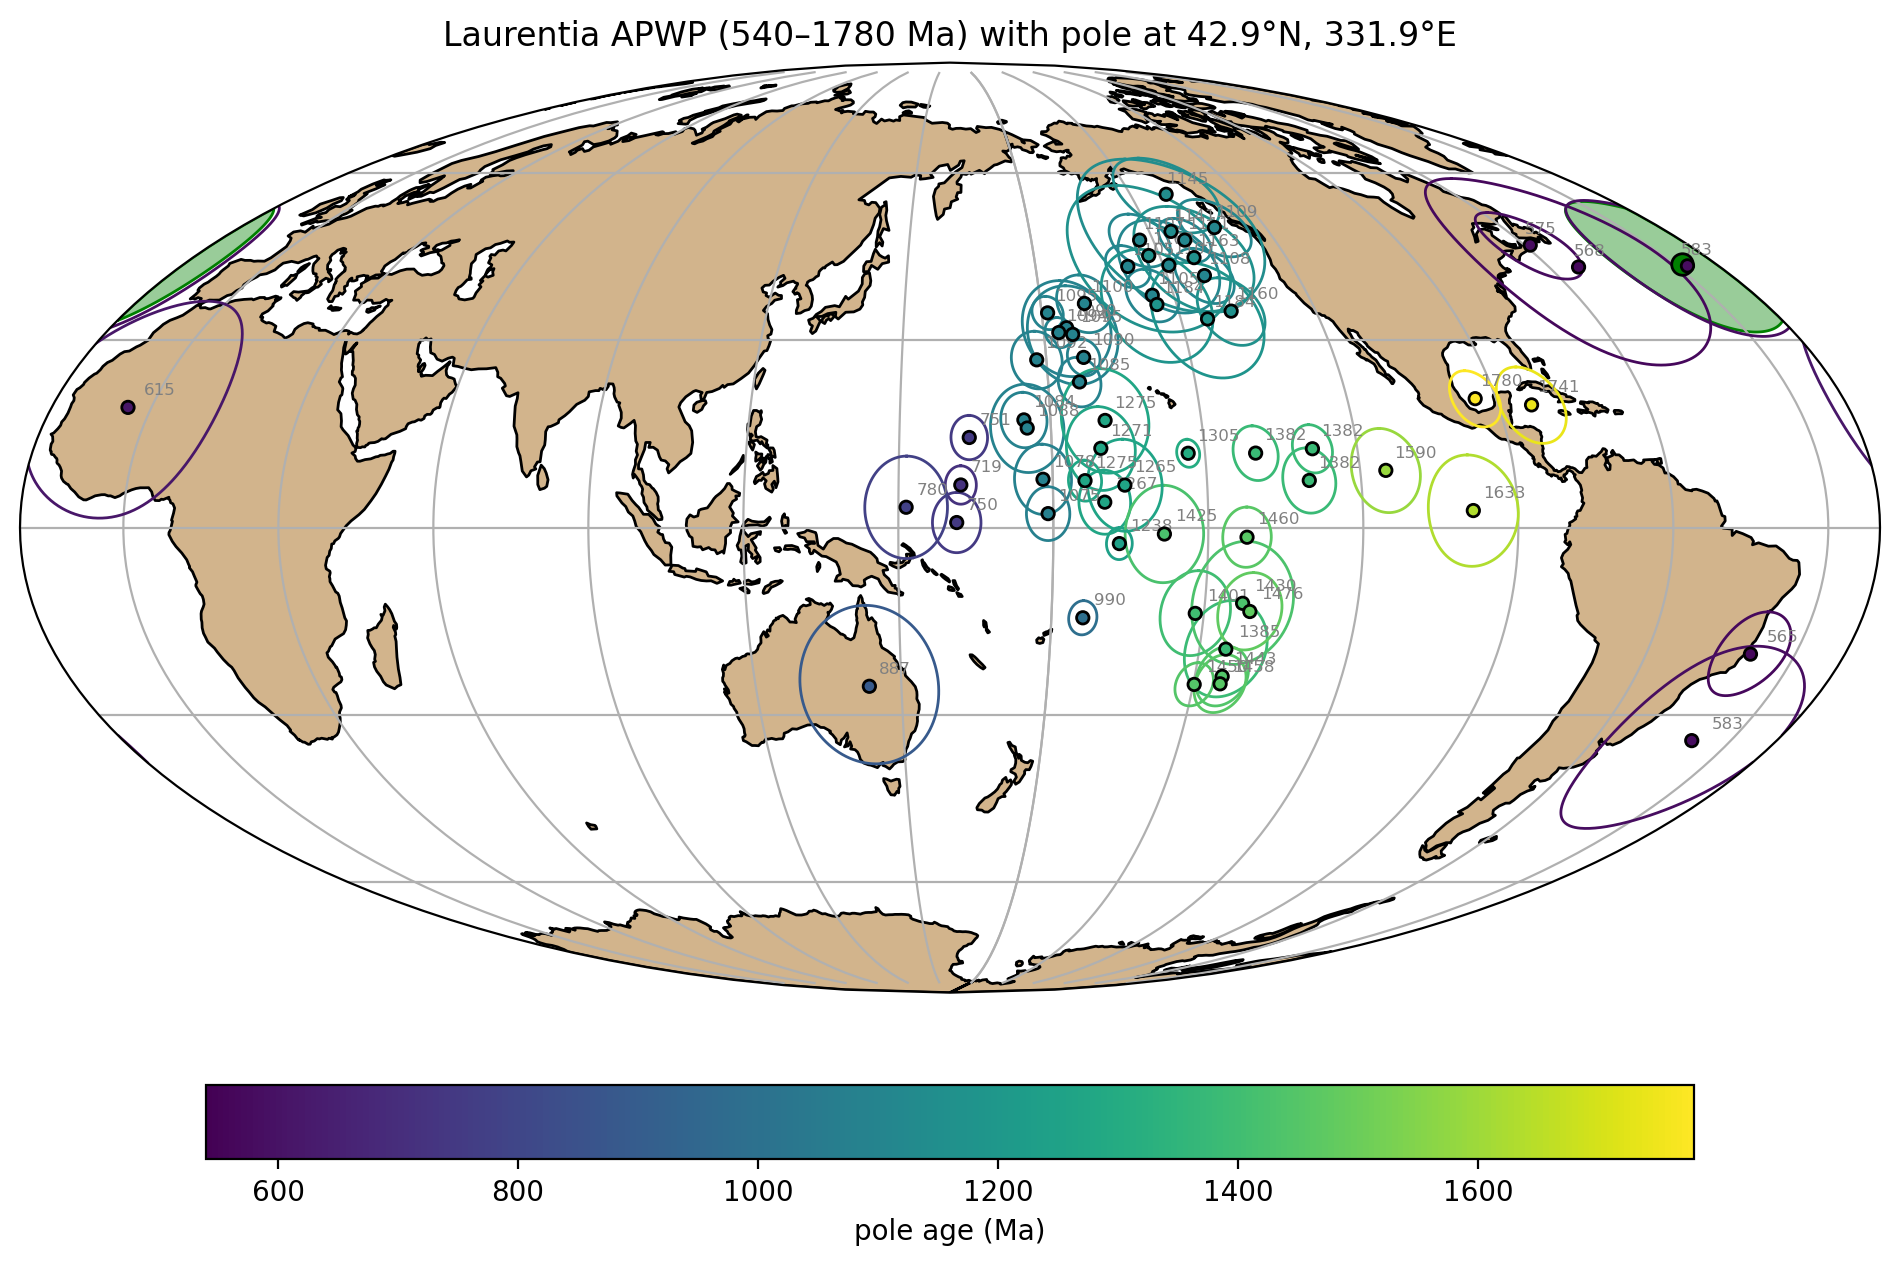

In [7]:
Laurentia_poles = pt.get_Laurentia_poles()
Laurentia_poles = pt.plot_apwp_context(Laurentia_poles, pole_mean_A['inc'], pole_mean_A['dec'], pole_mean_A['alpha95'])

## R2: Techniques and statistical analysis (ChRM A; Meert et al., 2020)

R2(c) is scored from the recreated site data; (a)/(b) are advisory. McCausland et al. (2011) used both AF and thermal demagnetization with PCA and great-circle analysis.

R2 assessment (Meert et al., 2020):
  (a) two demag methods (AF + thermal)  [advisory, from method_codes]: yes
  (b) PCA / great-circle component analysis  [advisory, from method_codes]: yes
      note: method codes are inconsistently applied; confirm (a)/(b) against the source publication.
  (c) adequate PSV sampling [scored]:
        N = 55 samples (>= 25): PASS
        K = 24.0 (10-70): PASS
        B = 8 sites (>= 8): PASS
        min 5 samples/site (>= 3): PASS
        A95 = 11.5 in Deenen envelope [5.2, 22.1]: PASS
  => R2 (from sub-criterion c) = 1

A_95 of 11.5 passes Deenen et al. (2011) criteria of being between 5.2 and 22.1 for this number of sites


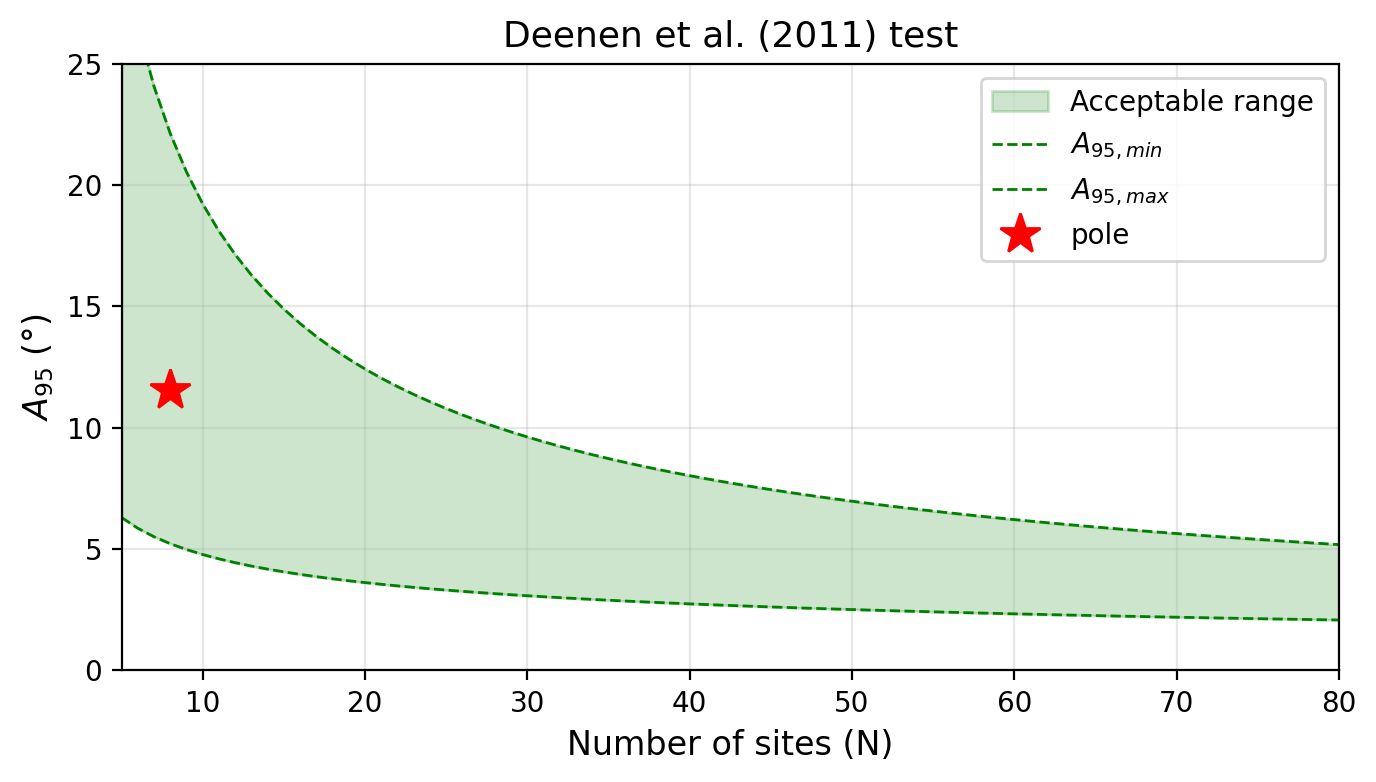

In [8]:
r2_A = pt.assess_R2(sites_A, pole_mean_A)
print()
pt.Deenen_test(pole_mean_A['n'], pole_mean_A['alpha95'])
pt.plot_Deenen_test(pole_mean_A)
plt.show()

Not enough sites for the Fisher Q-Q or SVEI secular variation assessments.

## R7: Comparison with younger Laurentia poles (ChRM A)

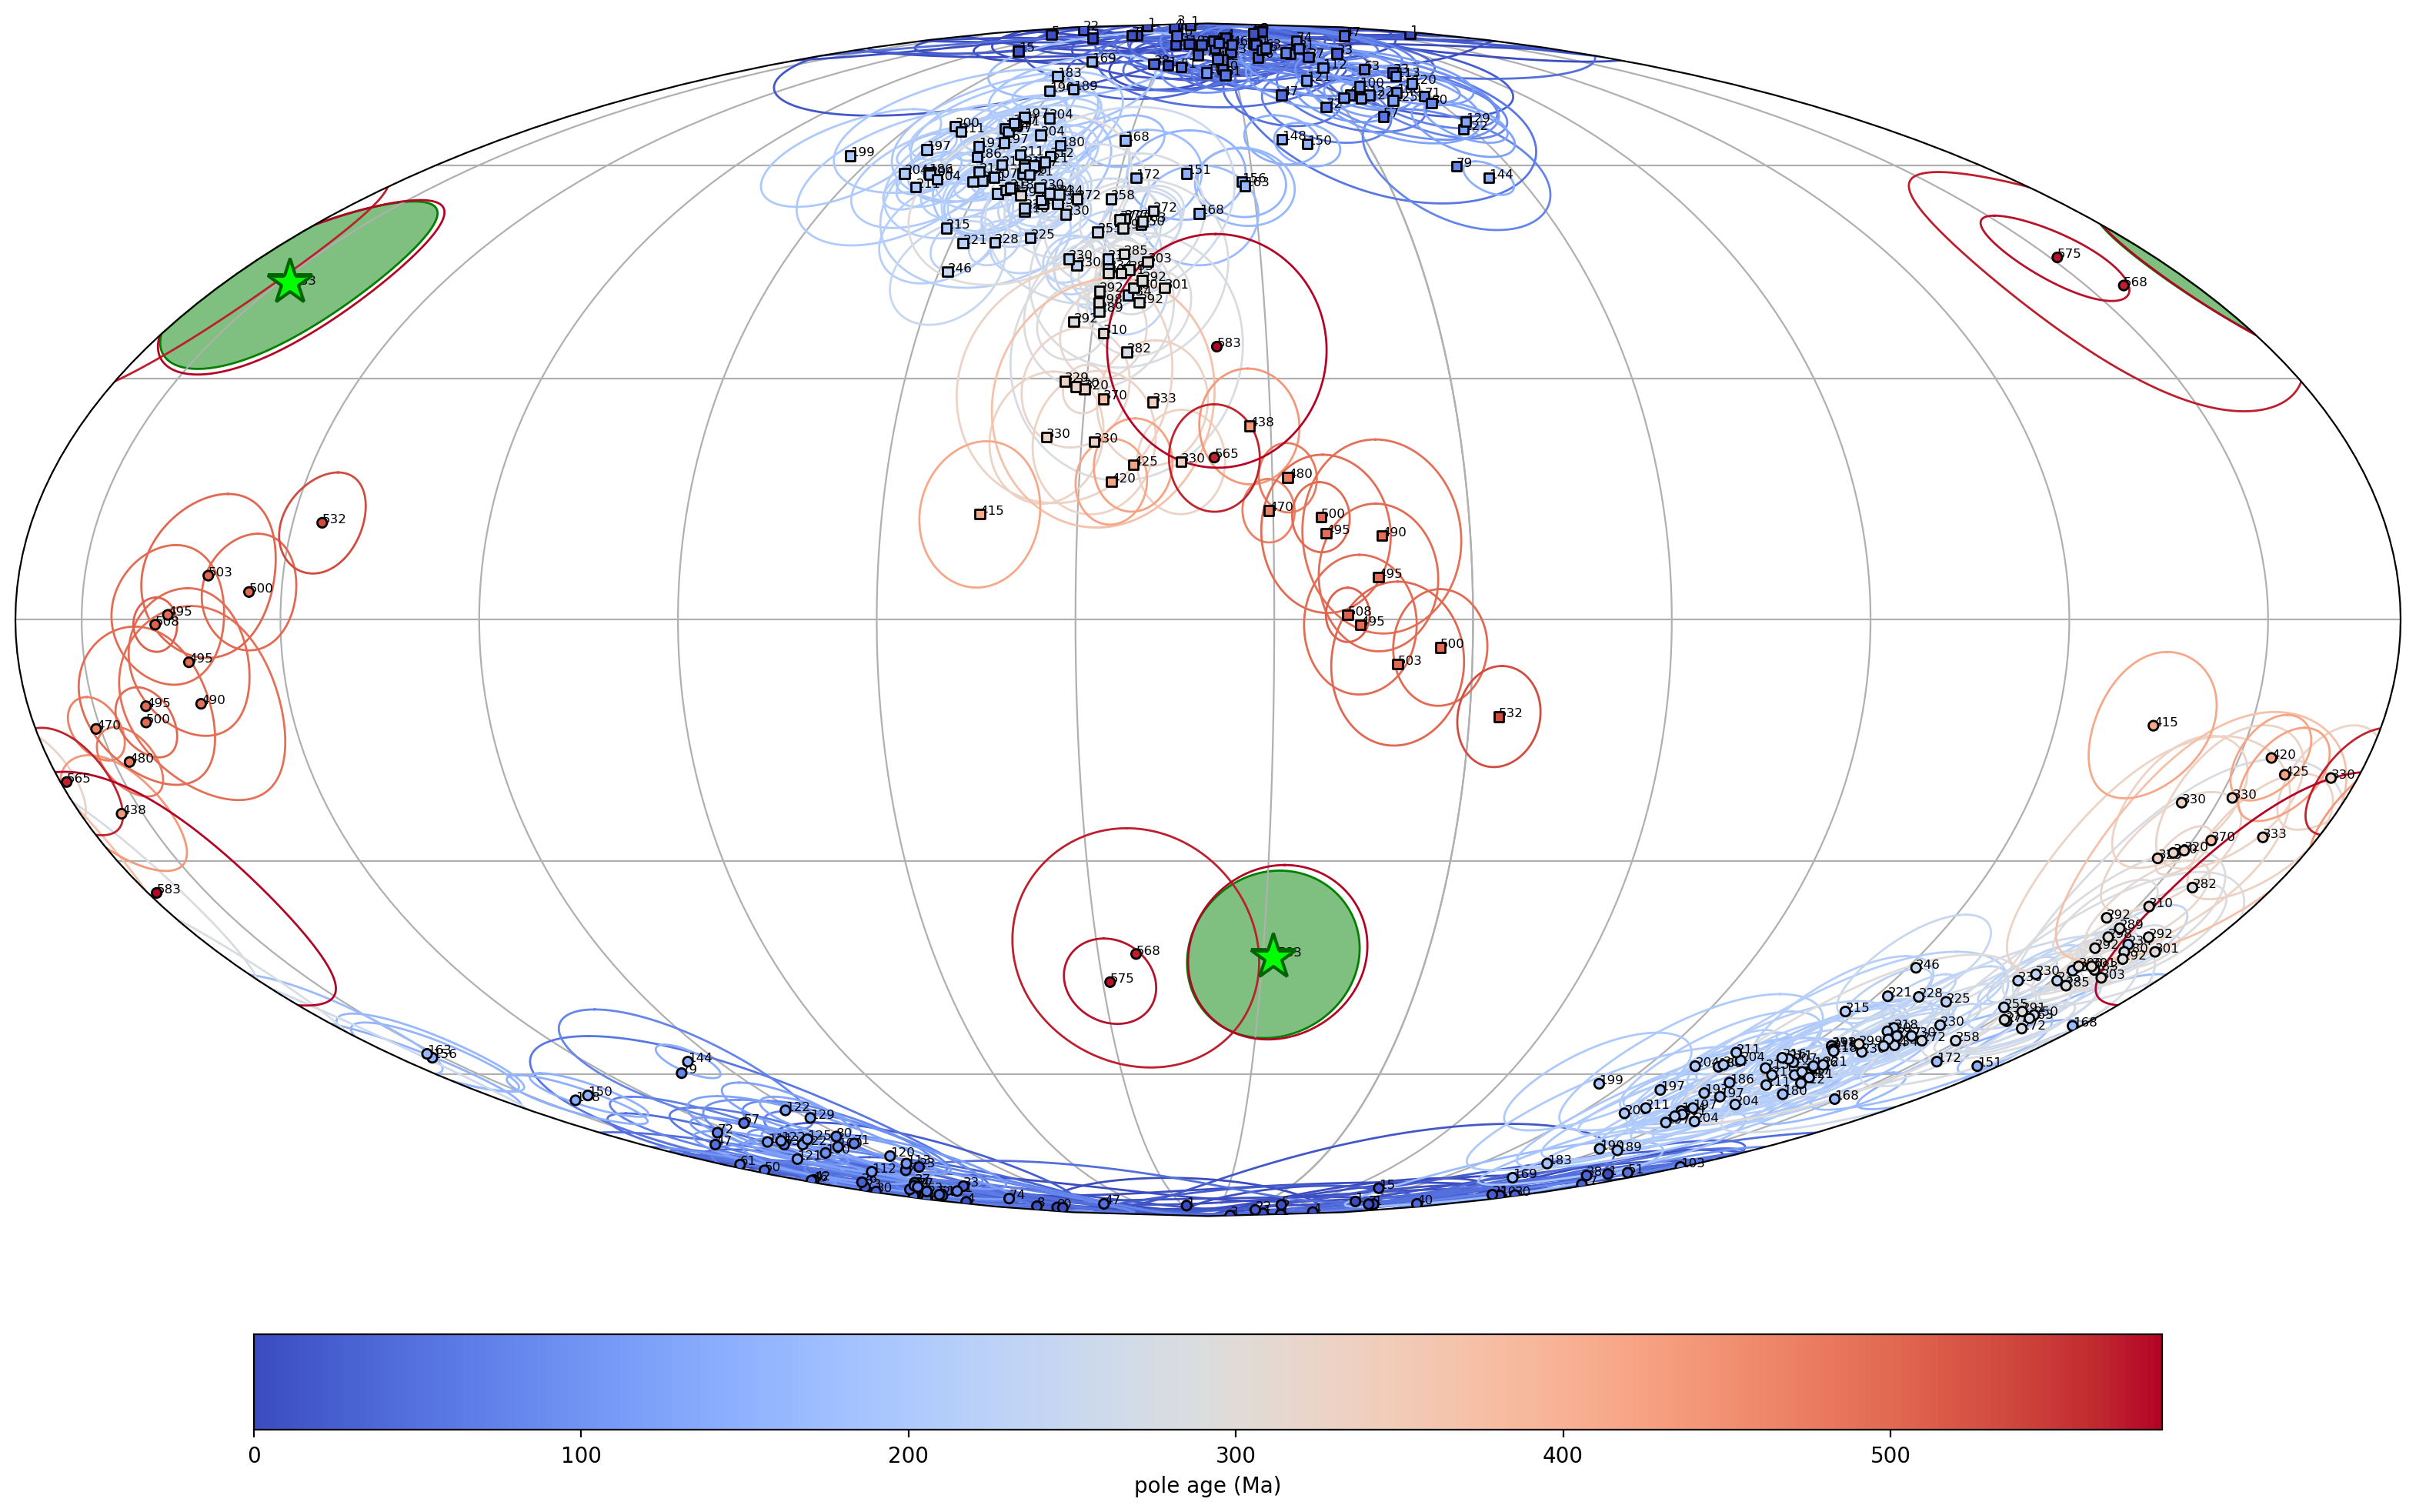

In [9]:
Laurentia_stricto_poles = pt.get_Laurentia_stricto_poles()
pt.plot_pole_overlap('Baie des Moutons complex A', Laurentia_stricto_poles, pt.Torsvik2012_Laurentia,
                  pole_plat=pole_mean_A['inc'], pole_plon=pole_mean_A['dec'],
                  pole_A95=pole_mean_A['alpha95'])
plt.show()

## R-score summary (ChRM A; Meert et al., 2020)

R1–R6 carried from the prior compilation (McCausland et al., 2011; Nordic pre-workshop); R7 reassessed below.

| R | Criterion | Score | Justification |
|---|---|---|---|
| 1 | Age within ± 15 Ma | **1** | Weighted-mean hornblende ⁴⁰Ar–³⁹Ar plateau age of 583.4 ± 2.0 Ma dates the complex (McCausland et al., 2011). |
| 2 | Techniques and statistical analysis | **1** | AF + thermal demagnetization, PCA + great circles, Fisher site means. N = 8 sites, k = 24, A95 = 11.5° passes the Deenen et al. (2011) envelope; B = 8 ≥ 8. |
| 3 | Magnetic mineralogy characterized | **1** | ChRM A retained by PSD magnetite, characterized by stepwise thermal/AF demagnetization and LTD (McCausland et al., 2011). |
| 4 | Field tests constrain age of magnetization | **0** | Baked-contact tests at six sites were inconclusive (no stable remanence in the host syenite). |
| 5 | Structural control / tectonic coherence | **1** | Anorogenic nested-cone intrusion in cratonic Laurentia; varied dyke orientations interpreted to indicate it has not been significantly tilted since emplacement. |
| 6 | Presence of reversals | **0** | ChRM A is of a single polarity; no reversal test. |
| 7 | No resemblance to younger poles | **1** | The ChRM A pole resembles three ca. 590–570 Ma high-latitude Laurentia poles; none substantially younger (> a period) with R ≥ 3 overlaps in the R7 test. |
| | **Total R-score** | **5/7** | |

### ChRM A pole

| Quantity | This study (site VGPs) | McCausland et al. (2011) | Previous Nordic compilation |
|---|---|---|---|
| Component | ChRM A | A (steep) | A direction |
| N (sites) | 8 | 8 | 8 |
| N (specimens) | 55 | — | 87 |
| Dec (°) | 98.6 | 98.6 | 98.6 |
| Inc (°) | 78.0 | 78.0 | 78 |
| k (direction) | 71.8 | 71.7 | 71.1 |
| α95 (direction, °) | 6.6 | 6.5 | 6.8 |
| Pole lat (°N) | 42.9 | 42.6 | 42.6 |
| Pole lon (°E) | 331.9 | 332.7 | 332.7 |
| A95, pole (°) | 11.5 | — (oval dp/dm only) | 12.0 |
| dp / dm (°) | — / — | 11.7 / 12.4 | 11.7 / 12.4 |

In [10]:
Baie_A_summary = pt.make_nordic_summary(
    terrane='Laurentia',
    rockname='Baie des Moutons complex A',
    sites=sites_A,
    dir_mean=dir_mean_A,
    pole_mean=pole_mean_A,
    study_lon=study_lon,
    study_lat=study_lat,
    component_comment='ChRM A characteristic remanent magnetization (geographic coordinates)',
    tests='baked-contact tests inconclusive (no stable remanence in host syenite)',
    gpmdb_number='9364',
    magic_id='',
    percent_reversed=0,
    demag_code=4,
    R1=1, R2=1, R3=1, R4=0, R5=1, R6=0, R7=1,
    Grade='B',
    nominal_age=583.4,
    lomagage=581.4,
    himagage=585.4,
    REF_method="- ⁴⁰Ar–³⁹Ar geochronology are used to constrain the age with the weighted-mean of four hornblende plateau ages giving **583.4 ± 2.0 Ma** (McCausland et al., 2011), which dates the complex and is the current age constraint on the poles. (An older whole-rock K–Ar age of 575 Ma was reported by Doig & Barton, 1968.)\n\nPrevious Nordic compilation stated that: *583.4±2.0 weighted mean of four hornblende 40Ar–39Ar plateau ages from sites 20 and 44, McCausland et al 2011*",
    POLE_AUTHORS='McCausland, P. J. A., Hankard, F., Van der Voo, R., & Hall, C. M.',
    YEAR=2011,
    JOURNAL='Precambrian Research',
    VOLUME=187,
    VPAGES='58-78',
    TITLE='Ediacaran paleogeography of Laurentia: Paleomagnetism and 40Ar-39Ar geochronology of the 583 Ma Baie des Moutons syenite, Quebec',
    COMMENT='Pole calculated from site VGPs in Swanson-Hysell et al., 2026'
)
Baie_A_summary

,Terrane,ROCKNAME,RESULT#,COMPONENT,TESTS,TILT,SLAT,SLONG,B,N,...,himagage,REF/method,ROCKNAME,POLE AUTHORS,YEAR,JOURNAL,VOLUME,VPAGES,TITLE,Comment
0,Laurentia,Baie des Moutons complex A,GPMDB:9364,ChRM A characteristic remanent magnetization (...,baked-contact tests inconclusive (no stable re...,0,50.84,301.04,8,55,...,585,Weighted-mean hornblende 40Ar-39Ar plateau age...,Baie des Moutons complex A,"McCausland, P. J. A., Hankard, F., Van der Voo...",2011,Precambrian Research,187,58-78,Ediacaran paleogeography of Laurentia: Paleoma...,Pole calculated from site VGPs in Swanson-Hyse...


In [11]:
pt.save_nordic_summary(Baie_A_summary, '583_Baie_des_Moutons_A')

'../data/nordic_summaries/583_Baie_des_Moutons_A.csv'

# ChRM B direction pole

The ChRM B pole is the Fisher mean of the 6 site VGPs (B direction). ChRM B is shallow, placing Laurentia at low paleolatitude (~3º).

## Mean pole from VGPs (ChRM B)

Plon: 321.9  Plat: -33.9
Number of directions in mean (n): 6
Angular radius of 95% confidence (A_95): 15.7
Precision parameter (k) estimate: 19.2


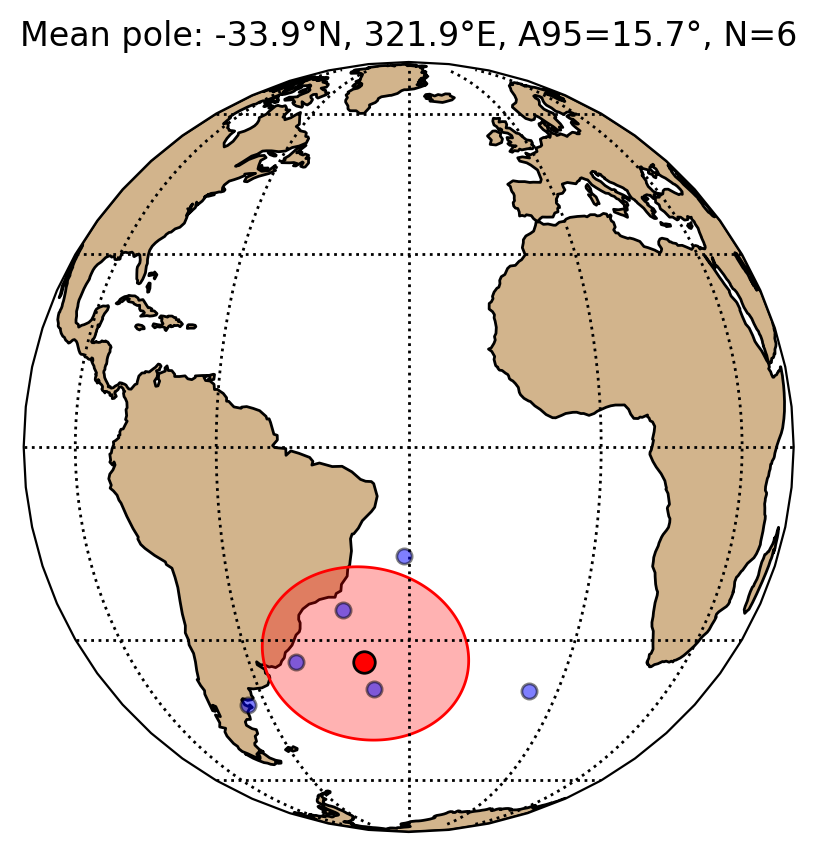

In [12]:
vgp_block_B, pole_mean_B = pt.compute_mean_pole(sites_B, unify_polarity=True, flip=True)
ipmag.print_pole_mean(pole_mean_B)
pole_plot_B = pt.plot_vgps_and_pole(vgp_block_B, pole_mean_B, central_longitude=330, figsize=(5,5))

## Site directions (ChRM B, as measured)

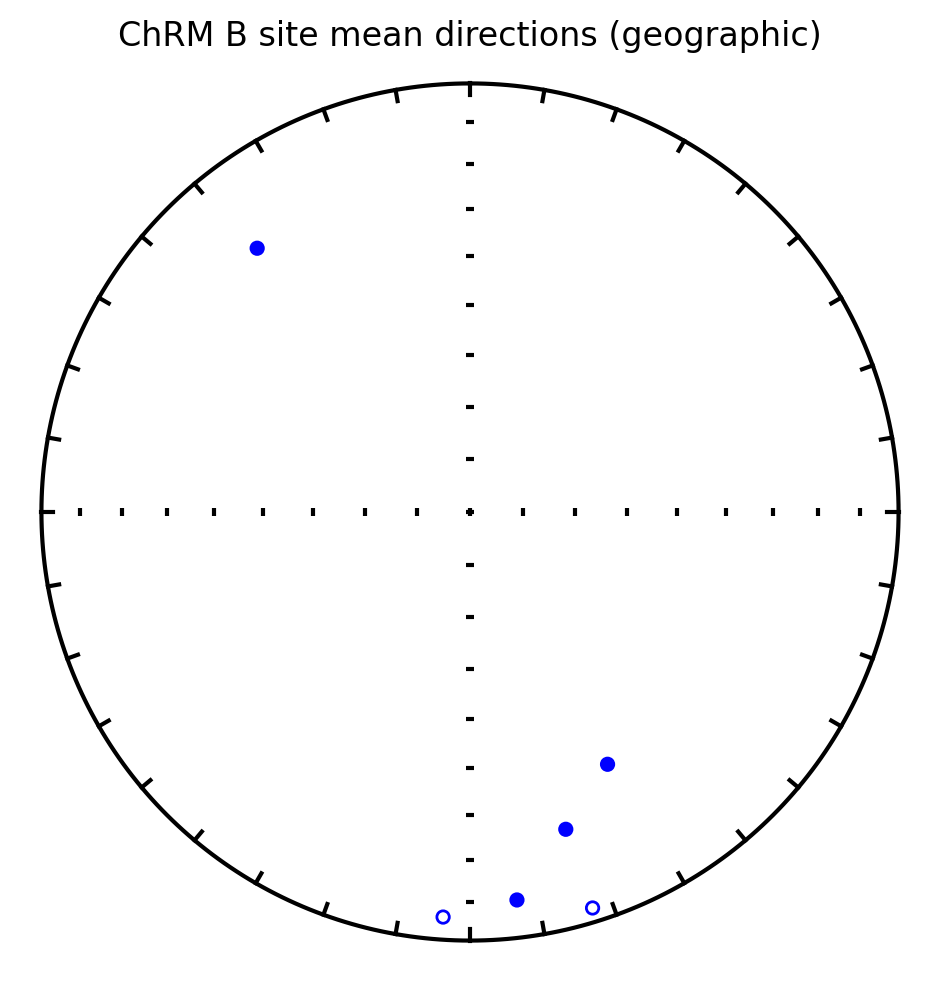

In [13]:
pt.plot_site_directions(sites_B, color='blue', marker='o',
                        title='ChRM B site mean directions (geographic)')
plt.show()

Calculating the mean reproduces the published mean direction (D=163.1, I=6.0, a95=21.7, k=10.5).

Dec: 163.1  Inc: 6.0
Number of directions in mean (n): 6
Angular radius of 95% confidence (a_95): 21.7
Precision parameter (k) estimate: 10.5


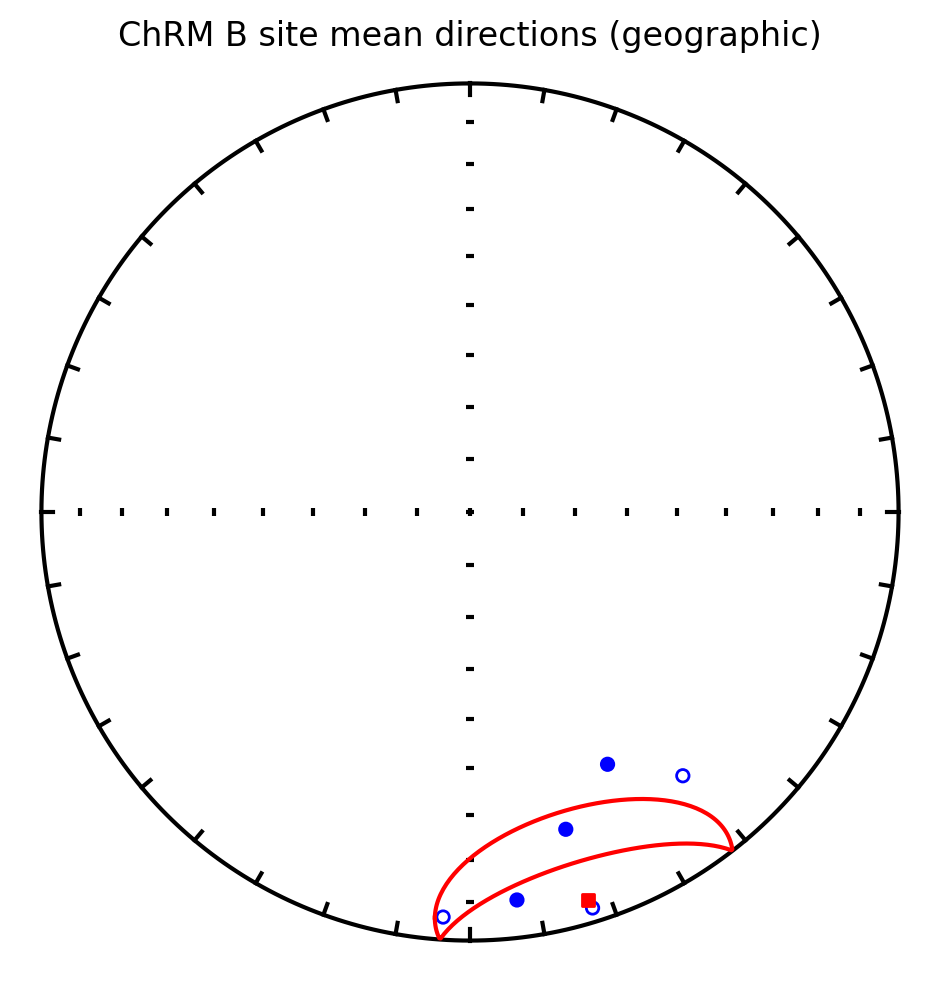

In [14]:
dir_block_B, dir_mean_B = pt.compute_mean_direction(sites_B, unify_polarity=True)
ipmag.print_direction_mean(dir_mean_B)

ipmag.plot_net()
ipmag.plot_di(di_block=dir_block_B, color='blue', marker='o')
ipmag.plot_di_mean(dir_mean_B['dec'], dir_mean_B['inc'], dir_mean_B['alpha95'],
                   color='red', marker='s')
ipmag.plt.title('ChRM B site mean directions (geographic)')
ipmag.plt.show()

## Pole in the context of the Laurentia APWP (ChRM B)

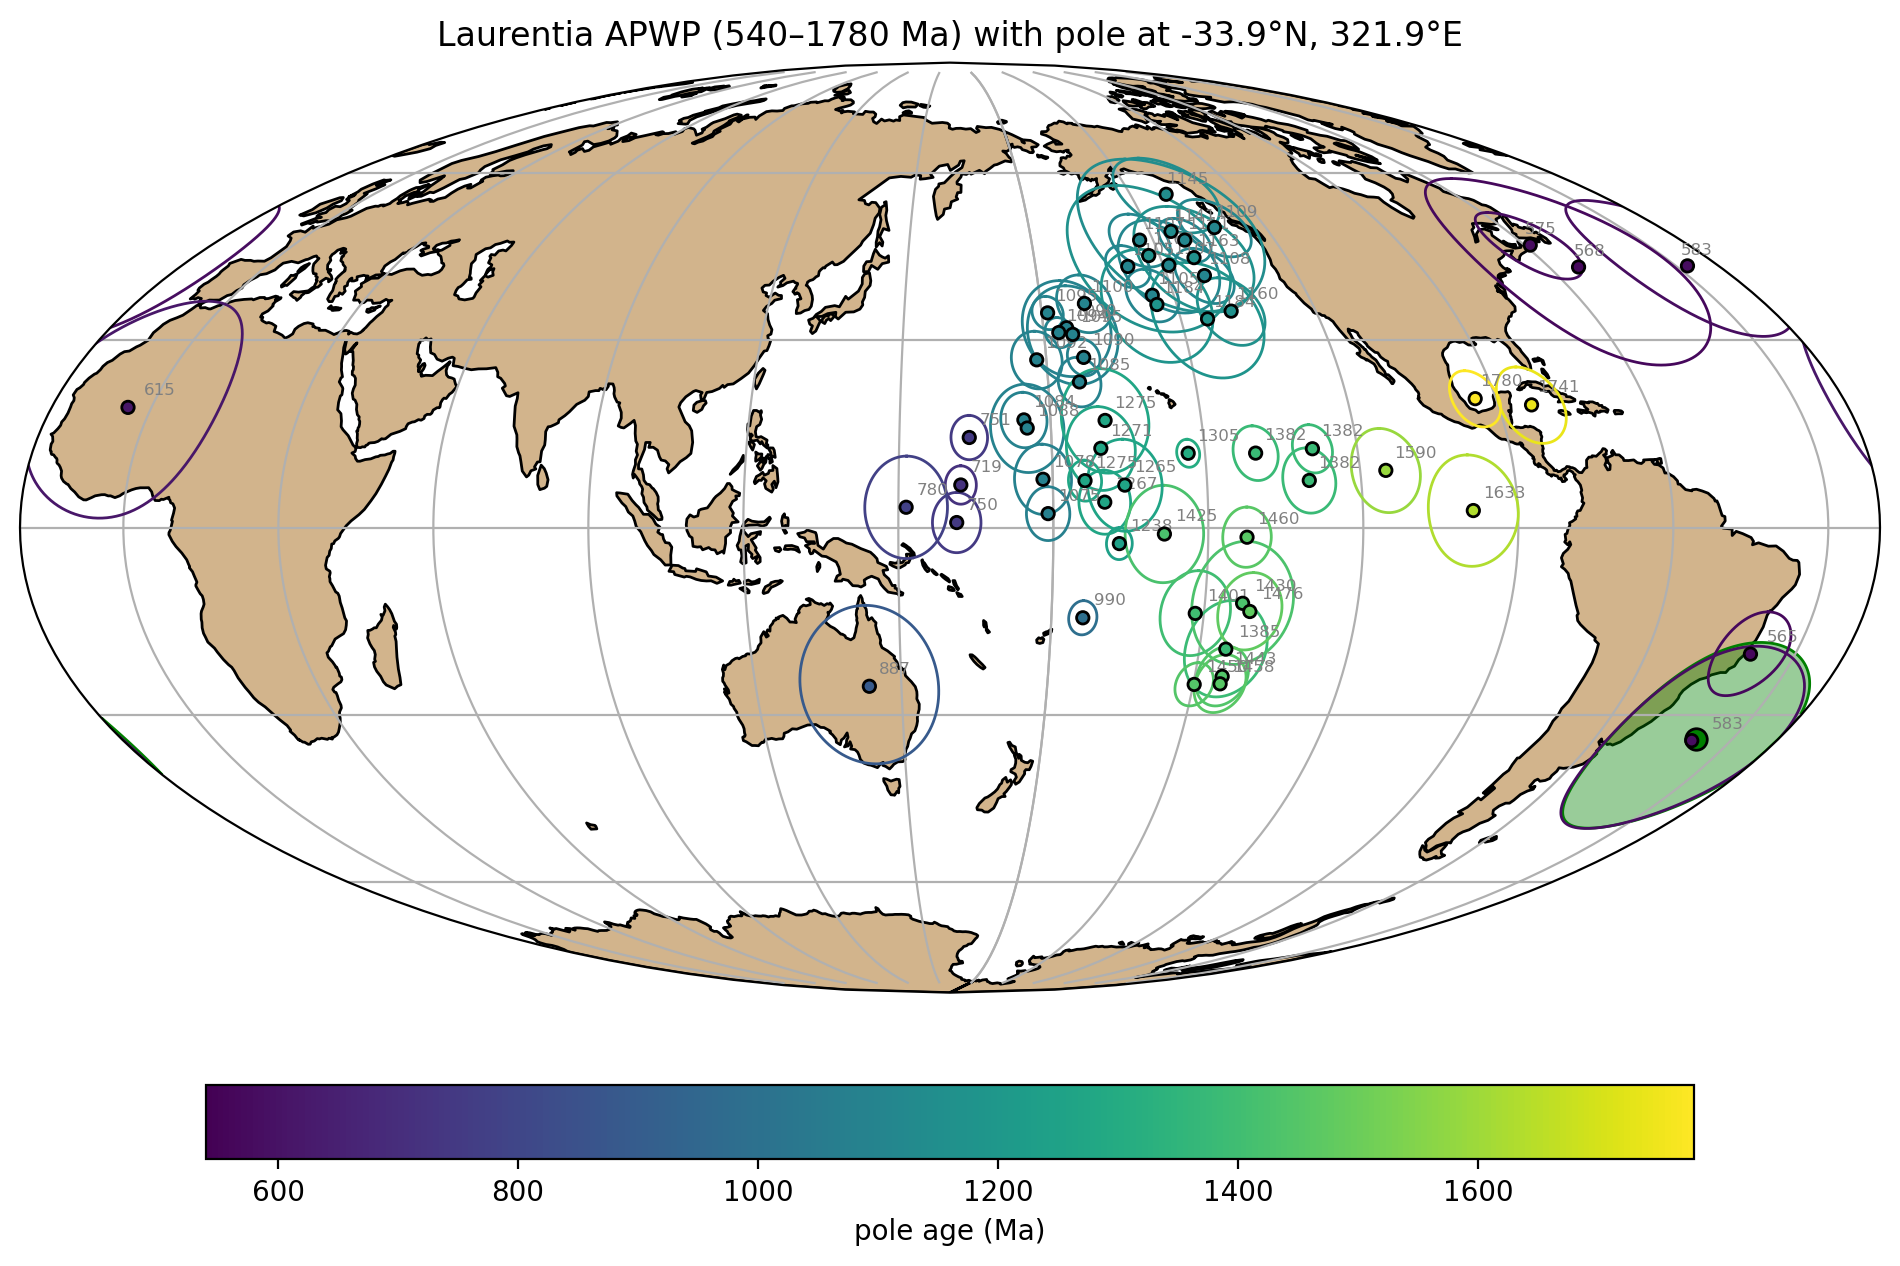

In [15]:
Laurentia_poles = pt.get_Laurentia_poles()
Laurentia_poles = pt.plot_apwp_context(Laurentia_poles, pole_mean_B['inc'], pole_mean_B['dec'], pole_mean_B['alpha95'])

## R2: Techniques and statistical analysis (ChRM B; Meert et al., 2020)

R2(c) is scored from the recreated site data. McCausland et al. (2011) used both AF and thermal demagnetization with PCA and great-circle analysis.

R2 assessment (Meert et al., 2020):
  (a) two demag methods (AF + thermal)  [advisory, from method_codes]: yes
  (b) PCA / great-circle component analysis  [advisory, from method_codes]: yes
      note: method codes are inconsistently applied; confirm (a)/(b) against the source publication.
  (c) adequate PSV sampling [scored]:
        N = 44 samples (>= 25): PASS
        K = 19.2 (10-70): PASS
        B = 6 sites (>= 8): FAIL
        min 5 samples/site (>= 3): PASS
        A95 = 15.7 in Deenen envelope [5.9, 26.5]: PASS
  => R2 (from sub-criterion c) = 0

A_95 of 15.7 passes Deenen et al. (2011) criteria of being between 5.9 and 26.5 for this number of sites


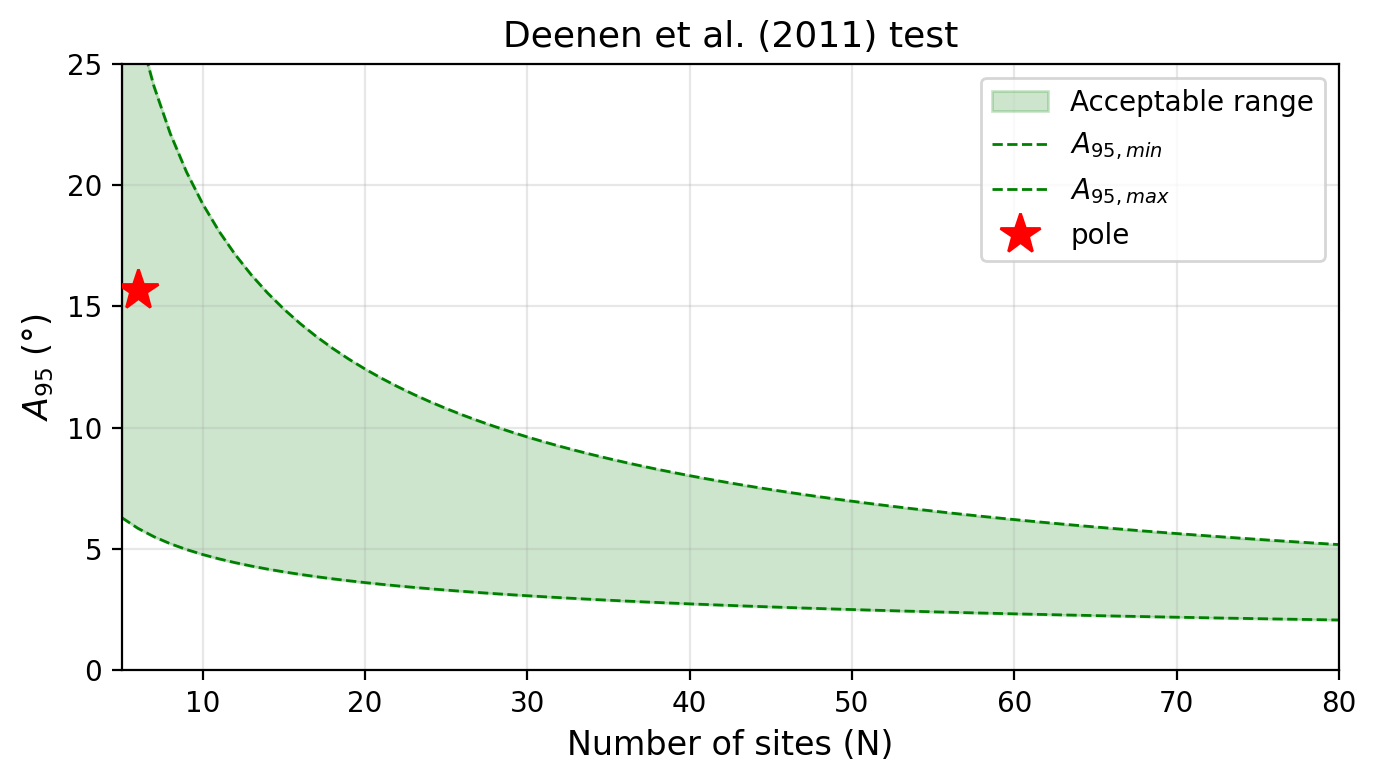

In [16]:
r2_B = pt.assess_R2(sites_B, pole_mean_B)
print()
pt.Deenen_test(pole_mean_B['n'], pole_mean_B['alpha95'])
pt.plot_Deenen_test(pole_mean_B)
plt.show()

### Supplementary: VGP distribution-shape diagnostics (ChRM B)

In [17]:
fishqq_B = pt.fishqq_vgps(sites_B, unify_polarity=True)
fishqq_B

you need N> 10 for at least one mode


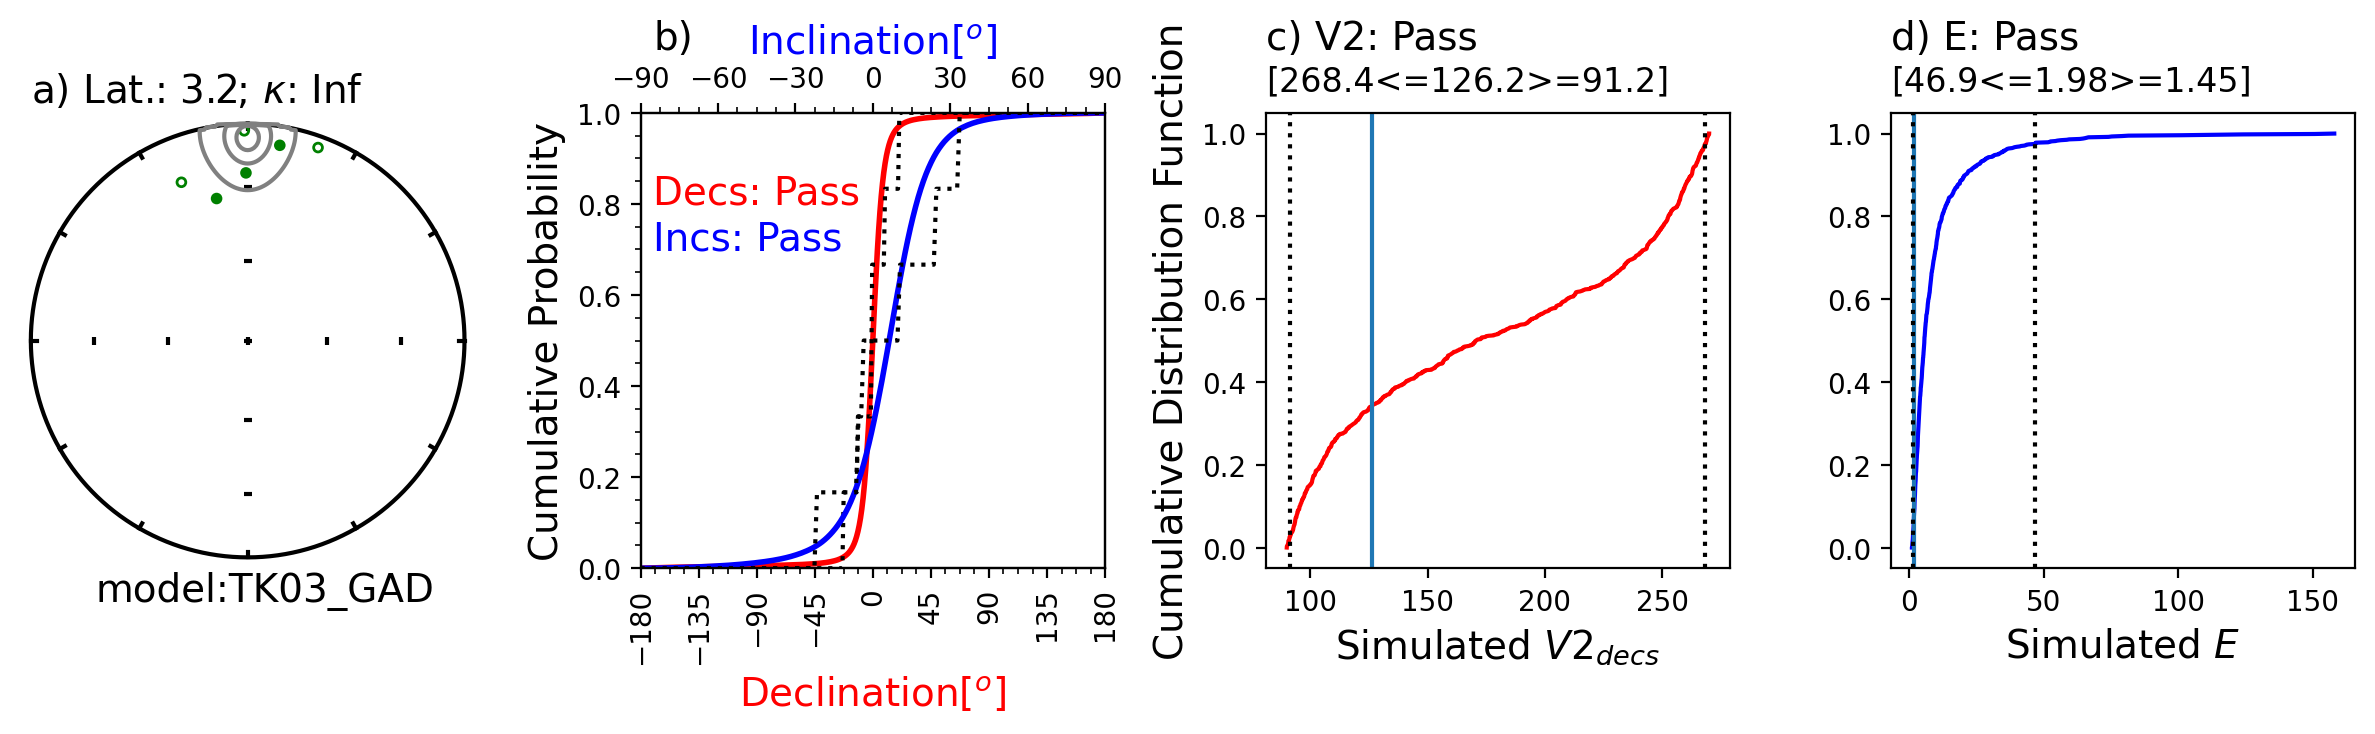

paleolatitude = 3.2°
elongation E = 1.98 (model 95% bounds 1.45–46.90; consistent)


In [18]:
# The SVEI elongation/inclination diagnostic is only weakly constrained at
# this small site count (N=6); it is reported where it runs.
try:
    svei_B = pt.svei_test_vgps(sites_B, study_lon, study_lat, model='TK03_GAD', plot=True)
    print(f"paleolatitude = {svei_B['lat']:.1f}°")
    print(f"elongation E = {svei_B['E']:.2f} "
          f"(model 95% bounds {svei_B['Esim_min']:.2f}–{svei_B['Esim_max']:.2f}; "
          f"{'consistent' if svei_B['E_result'] else 'inconsistent'})")
except Exception as exc:
    print(f"SVEI test could not be completed for the ChRM B distribution: {exc}")
    print("(The observed elongation falls outside the simulated range; with only "
          "6 sites the elongation/inclination diagnostic is unreliable here.)")

## R7: Comparison with younger Laurentia poles (ChRM B)

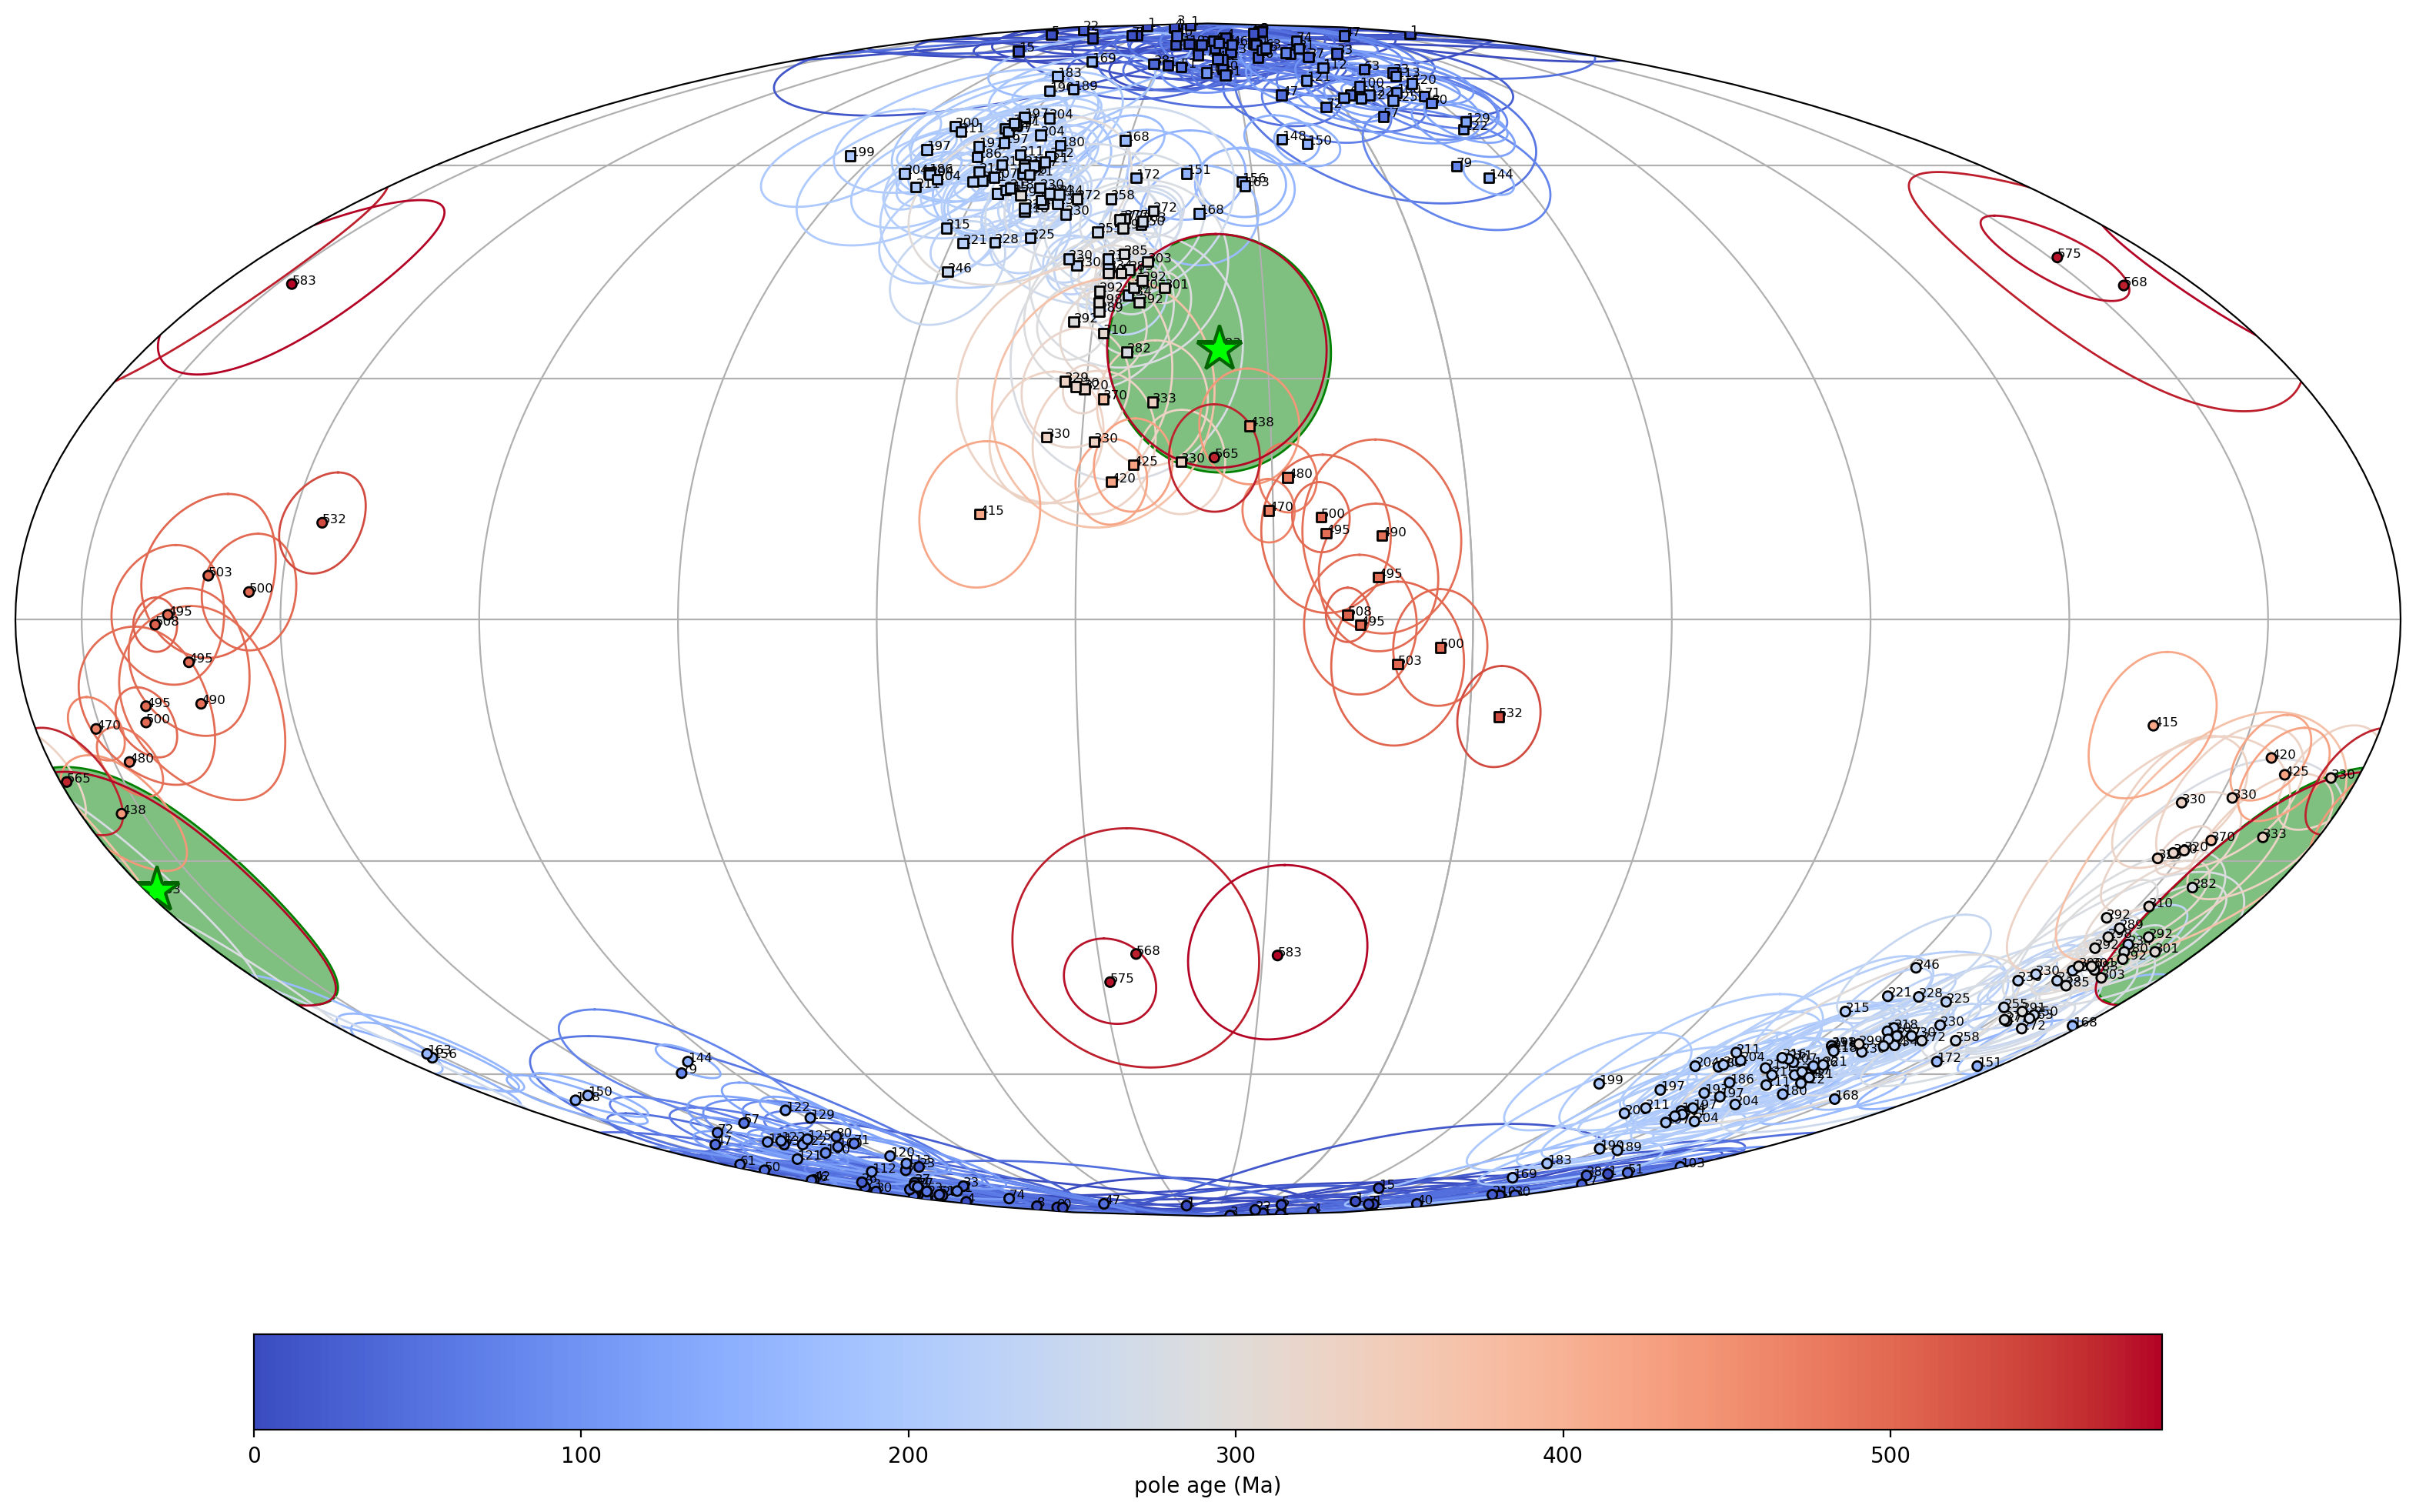

<GeoAxes: >

In [19]:
Laurentia_stricto_poles = pt.get_Laurentia_stricto_poles()
pt.plot_pole_overlap('Baie des Moutons complex B', Laurentia_stricto_poles, pt.Torsvik2012_Laurentia,
                  pole_plat=pole_mean_B['inc'], pole_plon=pole_mean_B['dec'],
                  pole_A95=pole_mean_B['alpha95'])

## R-score summary (ChRM B; Meert et al., 2020)

R1–R6 carried from the prior compilation; R7 reassessed below.

| R | Criterion | Score | Justification |
|---|---|---|---|
| 1 | Age within ± 15 Ma | **1** | The host complex is dated at 583.4 ± 2.0 Ma (⁴⁰Ar–³⁹Ar; McCausland et al., 2011); the ChRM B carriers (dykes, late syenite) belong to the same complex. |
| 2 | Techniques and statistical analysis | **0** | Although N = 44 samples, K = 19, and A95 = 15.7° pass, there are only **B = 6 sites** (< 8 required), so R2(c) is not met. |
| 3 | Magnetic mineralogy characterized | **1** | Remanence carriers characterized by stepwise demagnetization and LTD (McCausland et al., 2011). |
| 4 | Field tests constrain age of magnetization | **0** | Baked-contact tests were inconclusive. |
| 5 | Structural control / tectonic coherence | **1** | Same untilted, cratonic nested-cone complex as ChRM A. |
| 6 | Presence of reversals | **0** | A single reversed site (MB20) is suggestive of a reversal but is not a statistically significant antipodal reversal test (Meert et al., 2020, R6). |
| 7 | No resemblance to younger poles | **0** | The ChRM B pole overlaps with the younger ca. 565 Ma Sept-Îles pole (R ≥ 3) and like that pool overlaps with the Laurentia's late Paleozoic APWP. |
| | **Total R-score** | **3/7** | |

### ChRM B pole

| Quantity | This study (site VGPs) | McCausland et al. (2011) | Nordic compilation |
|---|---|---|---|
| Component | ChRM B | B (shallow) | B direction |
| N (sites) | 6 | 6 | 6 |
| N (specimens) | 44 | — | 56 |
| Dec (°) | 163.1 | 163.1 | 163.1 |
| Inc (°) | 6.0 | 6.0 | 6 |
| k (direction) | 10.5 | 10.5 | 10.5 |
| α95 (direction, °) | 21.7 | 21.7 | 21.7 |
| Pole lat (°N) | −33.9 | −34.2 | −34.2 |
| Pole lon (°E) | 321.9 | 321.5 | 321.5 |
| A95, pole (°) | 15.7 | — (oval dp/dm only) | 15.4 |
| dp / dm (°) | — / — | 10.9 / 21.8 | 10.9 / 21.8 |

The original study converted the directional mean to a pole with a dp/dm. We prefer using the pole calculated from the site-level VGPs.

In [20]:
Baie_B_summary = pt.make_nordic_summary(
    terrane='Laurentia',
    rockname='Baie des Moutons complex B',
    sites=sites_B,
    dir_mean=dir_mean_B,
    pole_mean=pole_mean_B,
    study_lon=study_lon,
    study_lat=study_lat,
    component_comment='ChRM B characteristic remanent magnetization (geographic coordinates)',
    tests='baked-contact tests inconclusive (no stable remanence in host syenite)',
    gpmdb_number='9365',
    magic_id='',
    percent_reversed=20,
    demag_code=4,
    R1=1, R2=0, R3=1, R4=0, R5=1, R6=0, R7=0,
    Grade='B',
    nominal_age=583.4,
    lomagage=581.4,
    himagage=585.4,
    REF_method="- ⁴⁰Ar–³⁹Ar geochronology are used to constrain the age with the weighted-mean of four hornblende plateau ages giving **583.4 ± 2.0 Ma** (McCausland et al., 2011), which dates the complex and is the current age constraint on the poles. (An older whole-rock K–Ar age of 575 Ma was reported by Doig & Barton, 1968.)\n\nPrevious Nordic compilation stated that: *583.4±2.0 weighted mean of four hornblende 40Ar–39Ar plateau ages from sites 20 and 44, McCausland et al 2011*",
    POLE_AUTHORS='McCausland, P. J. A., Hankard, F., Van der Voo, R., & Hall, C. M.',
    YEAR=2011,
    JOURNAL='Precambrian Research',
    VOLUME=187,
    VPAGES='58-78',
    TITLE='Ediacaran paleogeography of Laurentia: Paleomagnetism and 40Ar-39Ar geochronology of the 583 Ma Baie des Moutons syenite, Quebec',
    COMMENT='Like the younger Sept-Iles pole the pole overlaps with the late Paleozoic path which is when overprinting could be expected due to orogenesis on the margin. Pole calculated from site VGPs in Swanson-Hysell et al., 2026.'
)
Baie_B_summary

,Terrane,ROCKNAME,RESULT#,COMPONENT,TESTS,TILT,SLAT,SLONG,B,N,...,himagage,REF/method,ROCKNAME,POLE AUTHORS,YEAR,JOURNAL,VOLUME,VPAGES,TITLE,Comment
0,Laurentia,Baie des Moutons complex B,GPMDB:9365,ChRM B characteristic remanent magnetization (...,baked-contact tests inconclusive (no stable re...,0,50.84,301.04,6,44,...,585,The host complex has a weighted-mean hornblend...,Baie des Moutons complex B,"McCausland, P. J. A., Hankard, F., Van der Voo...",2011,Precambrian Research,187,58-78,Ediacaran paleogeography of Laurentia: Paleoma...,Like the younger Sept-Iles pole the pole overl...


In [21]:
pt.save_nordic_summary(Baie_B_summary, '583_Baie_des_Moutons_B')

'../data/nordic_summaries/583_Baie_des_Moutons_B.csv'